In [5]:
import sys
import os
import torch

# Adds the parent directory (chestxray-classification) to the path
sys.path.append(os.path.abspath(".."))

# Use an absolute import starting from the project root
from models.medical_sota.RadDINO.model import RadDINO

# 1. Define the device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# 2. Initialise and move model to GPU
model = RadDINO().to(device)

# 3. Load the .pth file and state_dict directly to GPU
# map_location ensures weights are moved to the correct device immediately
state_dict = torch.load('../models/medical_sota/RadDINO/raddino_best_model.pth', map_location=device, weights_only=True)

# 4. Replace the initial weights
model.load_state_dict(state_dict)

# 5. Set to evaluation mode (if performing inference)
model.eval()

Loading weights: 100%|██████████| 223/223 [00:00<00:00, 6611.55it/s]


RadDINO(
  (encoder): Dinov2Model(
    (embeddings): Dinov2Embeddings(
      (patch_embeddings): Dinov2PatchEmbeddings(
        (projection): Conv2d(3, 768, kernel_size=(14, 14), stride=(14, 14))
      )
      (dropout): Dropout(p=0.0, inplace=False)
    )
    (encoder): Dinov2Encoder(
      (layer): ModuleList(
        (0-11): 12 x Dinov2Layer(
          (norm1): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
          (attention): Dinov2Attention(
            (attention): Dinov2SelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
            )
            (output): Dinov2SelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.0, inplace=False)
            )
          )
          (layer_scale1): Dinov2LayerScale()
          (

In [6]:
import torch

# 1. Load your weights
weights_path = '../models/medical_sota/RadDINO/raddino_best_model.pth'
state_dict = torch.load(weights_path, map_location='cpu')

# 2. Find the correct key name dynamically
# RadDINO often uses 'model.pos_embed' or 'backbone.pos_embed'
pos_embed_key = next((k for k in state_dict.keys() if 'pos_embed' in k), None)

if pos_embed_key is None:
    print("Error: Could not find a key containing 'pos_embed'.")
    print("Available keys in this checkpoint are:", list(state_dict.keys())[:10])
else:
    # 3. Look at the position embedding shape
    pos_embed = state_dict[pos_embed_key]
    print(f"Using Key: {pos_embed_key}")
    print(f"Position Embedding Shape: {pos_embed.shape}")

    # 4. Calculate the grid size
    # Formula: sqrt(total_tokens - 1) 
    # (Subtract 1 for the [CLS] token)
    # The tokens are usually in the second dimension (index 1)
    num_patches = pos_embed.shape[1] - 1
    grid_size = int(num_patches**0.5)

    print(f"Grid Size: {grid_size}x{grid_size}")
    # Assuming a patch size of 14, common for RadDINO/ViT-S/14
    print(f"Original Input Resolution: {grid_size * 14}x{grid_size * 14}")


Error: Could not find a key containing 'pos_embed'.
Available keys in this checkpoint are: ['encoder.embeddings.cls_token', 'encoder.embeddings.mask_token', 'encoder.embeddings.position_embeddings', 'encoder.embeddings.patch_embeddings.projection.weight', 'encoder.embeddings.patch_embeddings.projection.bias', 'encoder.encoder.layer.0.norm1.weight', 'encoder.encoder.layer.0.norm1.bias', 'encoder.encoder.layer.0.attention.attention.query.weight', 'encoder.encoder.layer.0.attention.attention.query.bias', 'encoder.encoder.layer.0.attention.attention.key.weight']


In [7]:
# Use the exact key from your output
pos_embed = state_dict['encoder.embeddings.position_embeddings']
print(f"Shape: {pos_embed.shape}")

# Calculate grid size
# Position embeddings in this format are usually [1, num_tokens, dim]
num_tokens = pos_embed.shape[1] 
# Note: Check if 1 token is the CLS token
grid_size = int((num_tokens - 1)**0.5) 

print(f"Grid Size: {grid_size}x{grid_size}")
print(f"Resolution (if patch=16): {grid_size * 16}")
print(f"Resolution (if patch=14): {grid_size * 14}")


Shape: torch.Size([1, 1370, 768])
Grid Size: 37x37
Resolution (if patch=16): 592
Resolution (if patch=14): 518


Loading weights: 100%|██████████| 223/223 [00:00<00:00, 12262.12it/s]


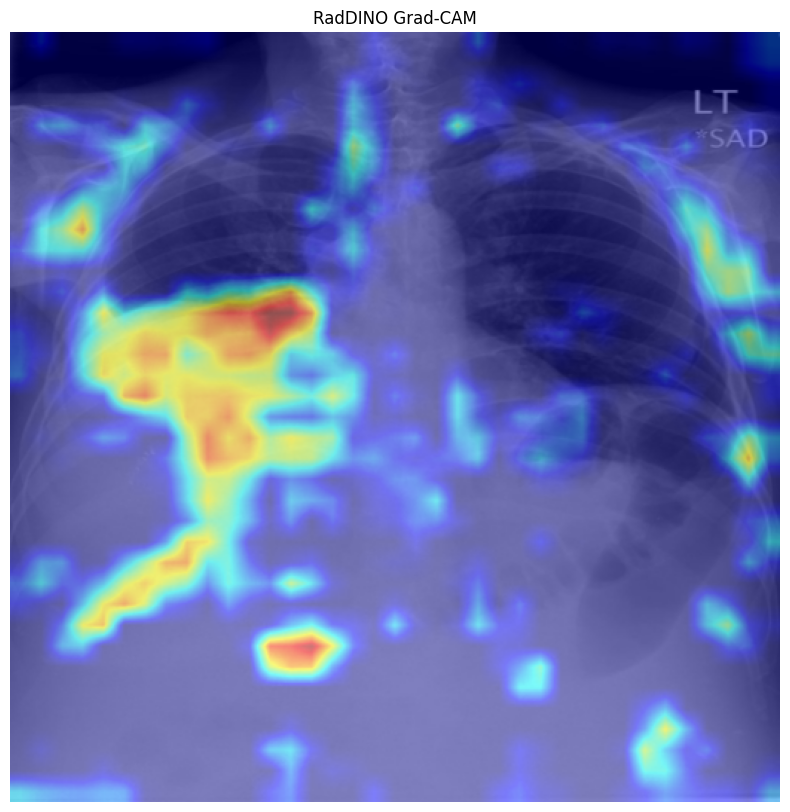

In [8]:
import sys
import os
import torch
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from torchvision import transforms
from PIL import Image

# 1. Path Setup
sys.path.append(os.path.abspath(".."))
from models.medical_sota.RadDINO.model import RadDINO

# ---------------------------------------------------------
# Reshape function for RadDINO (37x37 grid)
# ---------------------------------------------------------
def reshape_transform_vit(tensor, height=37, width=37):
    # RadDINO tokens: [Batch, 1370, Dim]. Index 0 is [CLS], 1-1369 are patches.
    result = tensor[:, 1:, :].reshape(tensor.size(0), height, width, tensor.size(2))
    return result.transpose(2, 3).transpose(1, 2)

# ---------------------------------------------------------
# MODEL WRAPPER: Forces the model to keep patch gradients
# ---------------------------------------------------------
class RadDINOGradWrapper(torch.nn.Module):
    def __init__(self, model):
        super().__init__()
        self.model = model
        
    def forward(self, x):
        # We call the encoder directly to ensure all tokens (CLS + Patches) 
        # are returned to Grad-CAM so the gradient doesn't become 'None'.
        # Note: If your model has a 'head', we apply it to the CLS token here.
        outputs = self.model.encoder(x)
        
        # Typically index 1 is the 'last_hidden_state' containing all tokens
        if isinstance(outputs, (list, tuple)):
            tokens = outputs[0]
        elif isinstance(outputs, dict):
            tokens = outputs.get('last_hidden_state', next(iter(outputs.values())))
        else:
            tokens = outputs
            
        # We return the CLS token (index 0) as the "prediction" 
        # but the library will hook the patches inside the encoder.
        return tokens[:, 0, :] 

def run_raddino_gradcam(image_path, model_weights_path):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    
    # 2. Initialize and Load
    raw_model = RadDINO().to(device)
    state_dict = torch.load(model_weights_path, map_location=device, weights_only=True)
    raw_model.load_state_dict(state_dict)
    raw_model.eval()

    # Apply the Wrapper
    model = RadDINOGradWrapper(raw_model)

    # 3. Target Layer
    # Based on your keys: encoder.encoder.layer.X.norm1
    target_layers = [model.model.encoder.encoder.layer[-1].norm1]

    # 4. Initialize Grad-CAM
    cam = GradCAM(
        model=model, 
        target_layers=target_layers, 
        reshape_transform=reshape_transform_vit
    )

    # 5. Preprocessing
    img = np.array(Image.open(image_path).convert('RGB'))
    img = cv2.resize(img, (518, 518)) 
    rgb_img = np.float32(img) / 255

    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])
    
    # CRITICAL FIX: Add .requires_grad_(True) to the input tensor
    input_tensor = transform(img).unsqueeze(0).to(device).requires_grad_(True)

    # 6. Generate Heatmap
    # Ensure gradients are enabled and we use the correct input_tensor
    model.eval()
    with torch.enable_grad():
        # Fixed the typo from your screenshot (input_tensor-input_tensor)
        grayscale_cam = cam(input_tensor=input_tensor, targets=None)
        grayscale_cam = grayscale_cam[0, :]
    
    cam_image = show_cam_on_image(rgb_img, grayscale_cam, use_rgb=True)

    # 7. Visualize
    plt.figure(figsize=(10, 10))
    plt.imshow(cam_image)
    plt.title('RadDINO Grad-CAM')
    plt.axis('off')
    plt.show()

if __name__ == "__main__":
    IMG_PATH = "../dataset/sample_xray.png"
    WEIGHTS_PATH = "../models/medical_sota/RadDINO/raddino_best_model.pth"
    run_raddino_gradcam(IMG_PATH, WEIGHTS_PATH)


## Changes Made to the Initial `gradcam_explainer.py` Code

Here is a summary of the 5 critical "fixes" made to the original code to get it running:
1. Dynamic Target Layer Path
Original: Used `model.blocks[-1]`.
Change: Switched to `model.encoder.encoder.layer[-1].norm1`.
Reason: Our specific RadDINO implementation (HuggingFace style) uses a deeper nested structure. I had to match the exact internal layer names found in our `.pth` file to give the library something to "hook" into.

2. Reshape Transform Scaling
Original: Set for a 14x14 grid (224px input).
Change: Updated to a 37x37 grid (518px input).
Reason: RadDINO/DINOv2 uses a 14x14 patch size. For a 518px medical image, this creates a 37x37 grid (518/14=37). If this didn't match the `pos_embed` tokens (1369+1=1370), the code would crash with a shape mismatch.

3. The Model Output Wrapper
Original: Passed the raw model directly.
Change: Created `RadDINOGradWrapper` to return a single Tensor.
Reason: Our model was likely returning a `Dictionary` or `Tuple`. Grad-CAM requires a raw Tensor to perform backpropagation. The wrapper "unpacks" the model output so the library can calculate gradients.

4. Forced Gradient Tracking
Original: Relied on standard `model.eval()`.
Change: Added `with torch.enable_grad():` and `.requires_grad_(True)` on the input tensor.
Reason: This was the cause of the `NoneType` and `RuntimeError`. Even though we are evaluating, Grad-CAM must perform a backward pass to see which pixels influenced the prediction. Without these lines, PyTorch "detaches" the graph to save memory, leaving the library with no data.

5. Library Versioning Fixes
Original: Used `use_cuda=True`.
Change: Removed the `use_cuda` argument.
Reason: The latest `pytorch-grad-cam` library (version 1.5+) removed this parameter and now detects the device automatically. Keeping it was causing a `TypeError`.

Loading weights: 100%|██████████| 223/223 [00:00<00:00, 12341.07it/s]
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.64..2.117904].


Top predicted class: Effusion


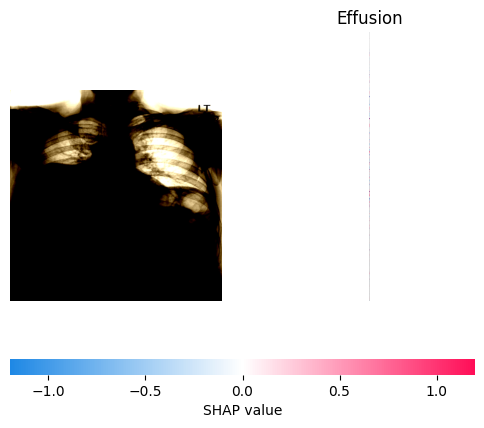

In [9]:
import sys
import os
import torch
import numpy as np
import shap
import matplotlib.pyplot as plt
from torchvision import transforms
from PIL import Image

sys.path.append(os.path.abspath(".."))
from models.medical_sota.RadDINO.model import RadDINO

CLASS_NAMES = [
    'Atelectasis', 'Cardiomegaly', 'Effusion', 'Infiltration', 'Mass',
    'Nodule', 'Pneumonia', 'Pneumothorax', 'Consolidation', 'Edema',
    'Emphysema', 'Fibrosis', 'Pleural_Thickening', 'Hernia'
]

def run_raddino_shap(image_path, model_weights_path):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    model = RadDINO().to(device)
    state_dict = torch.load(model_weights_path, map_location=device, weights_only=True)
    model.load_state_dict(state_dict)
    model.eval()

    transform = transforms.Compose([
        transforms.Resize((518, 518)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])

    img = Image.open(image_path).convert('RGB')
    input_tensor = transform(img).unsqueeze(0).to(device)

    # Black image as baseline (same approach as Hans' prediction_explainer.py)
    background = torch.zeros(1, 3, 518, 518).to(device)

    explainer = shap.GradientExplainer(model, background)
    shap_values, indexes = explainer.shap_values(input_tensor, ranked_outputs=1)

    # [batch, C, H, W] -> [batch, H, W, C] (same swapaxes as Hans' code)
    shap_numpy = [np.swapaxes(np.swapaxes(s, 1, -1), 1, 2) for s in shap_values]
    test_numpy = np.swapaxes(np.swapaxes(input_tensor.cpu().numpy(), 1, -1), 1, 2)

    top_class_idx = indexes[0][0].item()
    print(f"Top predicted class: {CLASS_NAMES[top_class_idx]}")

    shap.image_plot(shap_numpy, -test_numpy, labels=[[CLASS_NAMES[top_class_idx]]])
    plt.show()

if __name__ == "__main__":
    IMG_PATH = "../dataset/sample_xray.png"
    WEIGHTS_PATH = "../models/medical_sota/RadDINO/raddino_best_model.pth"
    run_raddino_shap(IMG_PATH, WEIGHTS_PATH)